# Treinamento Simplificado do Modelo para a Rock Pi

Notebook enxuto para:
- reservar janelas de teste da Rock Pi por classe e condição operacional;
- garantir que essas janelas não participem do treino;
- treinar um modelo simples com features no domínio do tempo;
- exportar o modelo e os artefatos necessários para a aplicação embarcada.


## 1. Configuração do Ambiente

In [1]:
from pathlib import Path
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"
DATA_DIR = PROJECT_ROOT / "data"
IMAGES_DIR = PROJECT_ROOT / "images"
OUTPUTS_DIR = PROJECT_ROOT / "outputs"
ROCKPI_SAMPLES_DIR = OUTPUTS_DIR / "rockpi_test_samples"
MODEL_ARTIFACTS_DIR = OUTPUTS_DIR / "model_artifacts_rockpi_simplificado"

ROCKPI_SAMPLES_DIR.mkdir(parents=True, exist_ok=True)
MODEL_ARTIFACTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)
np.random.seed(42)


## 2. Definição dos Datasets e dos Parâmetros

In [2]:
mapa_classes = {
    0: "Normal",
    1: "Desgaste Superficial",
    2: "Dente Trincado",
    3: "Dente Lascado",
    4: "Dente Ausente",
}

config_datasets = {
    "1500_10": {
        "rpm": 1500.0,
        "torque_nm": 10.0,
        "condicao_operacao": "1500 rpm / 10 Nm",
    },
    "2700_25": {
        "rpm": 2700.0,
        "torque_nm": 25.0,
        "condicao_operacao": "2700 rpm / 25 Nm",
    },
}

fs = 10_000
pontos_por_linha = 200
duracao_linha_s = pontos_por_linha / fs
duracao_janela_s = 1.0
linhas_por_janela = int(duracao_janela_s / duracao_linha_s)
duracao_reserva_rockpi_s = 5.0
linhas_reserva_rockpi = int(duracao_reserva_rockpi_s / duracao_linha_s)

assert linhas_reserva_rockpi % linhas_por_janela == 0

print(f"Fs = {fs} Hz")
print(f"Linhas por janela de 1 s = {linhas_por_janela}")
print(f"Linhas reservadas para a Rock Pi por classe = {linhas_reserva_rockpi}")
print(f"Janelas reservadas por classe = {linhas_reserva_rockpi // linhas_por_janela}")


Fs = 10000 Hz
Linhas por janela de 1 s = 50
Linhas reservadas para a Rock Pi por classe = 250
Janelas reservadas por classe = 5


## 3. Carregamento dos Dados Brutos

In [3]:
datasets_brutos = {}
resumo_datasets = []

for nome_dataset, meta in config_datasets.items():
    x = np.load(DATA_DIR / f"x_{nome_dataset}.npy")
    y = np.load(DATA_DIR / f"y_{nome_dataset}.npy")
    z = np.load(DATA_DIR / f"z_{nome_dataset}.npy")
    gt = np.load(DATA_DIR / f"gt_{nome_dataset}.npy")

    datasets_brutos[nome_dataset] = {
        "x": x,
        "y": y,
        "z": z,
        "gt": gt,
        **meta,
    }

    resumo_datasets.append(
        {
            "dataset_operacao": nome_dataset,
            "condicao_operacao": meta["condicao_operacao"],
            "rpm": meta["rpm"],
            "torque_nm": meta["torque_nm"],
            "linhas": int(gt.shape[0]),
            "classes_unicas": sorted(np.unique(gt).tolist()),
        }
    )

resumo_datasets = pd.DataFrame(resumo_datasets)
display(resumo_datasets)


,dataset_operacao,condicao_operacao,rpm,torque_nm,linhas,classes_unicas
0,1500_10,1500 rpm / 10 Nm,1500.0,10.0,50000,"[0, 1, 2, 3, 4]"
1,2700_25,2700 rpm / 25 Nm,2700.0,25.0,50000,"[0, 1, 2, 3, 4]"


## 4. Reserva e Exportação das Amostras de Teste da Rock Pi

In [4]:
def reservar_e_exportar_amostras_rockpi(datasets_info):
    datasets_para_treino = {}
    registros_exportacao = []

    for nome_dataset, info in datasets_info.items():
        gt = info["gt"]
        indices_treino_por_classe = {}

        for classe in sorted(mapa_classes):
            indices_classe = np.flatnonzero(gt == classe)
            if indices_classe.shape[0] < linhas_reserva_rockpi:
                raise ValueError(
                    f"{nome_dataset} não possui linhas suficientes para reservar {duracao_reserva_rockpi_s:.1f} s da classe {classe}."
                )

            indices_reservados = indices_classe[:linhas_reserva_rockpi]
            indices_treino = indices_classe[linhas_reserva_rockpi:]
            indices_treino_por_classe[classe] = indices_treino

            x_rows = info["x"][indices_reservados]
            y_rows = info["y"][indices_reservados]
            z_rows = info["z"][indices_reservados]
            gt_rows = gt[indices_reservados]

            caminho_npz = ROCKPI_SAMPLES_DIR / f"rockpi_raw_{nome_dataset}_classe_{classe}_{int(duracao_reserva_rockpi_s)}s.npz"

            np.savez(
                caminho_npz,
                dataset_operacao=nome_dataset,
                condicao_operacao=info["condicao_operacao"],
                rpm=info["rpm"],
                torque_nm=info["torque_nm"],
                classe=classe,
                classe_nome=mapa_classes[classe],
                fs=fs,
                pontos_por_linha=pontos_por_linha,
                duracao_linha_s=duracao_linha_s,
                duracao_total_s=duracao_reserva_rockpi_s,
                linha_inicial_classe_reconstruida=0,
                linha_final_classe_reconstruida=linhas_reserva_rockpi,
                indices_linhas_origem=indices_reservados,
                x_rows=x_rows,
                y_rows=y_rows,
                z_rows=z_rows,
                gt_rows=gt_rows,
                x_flat=x_rows.reshape(-1),
                y_flat=y_rows.reshape(-1),
                z_flat=z_rows.reshape(-1),
            )

            registros_exportacao.append(
                {
                    "dataset_operacao": nome_dataset,
                    "condicao_operacao": info["condicao_operacao"],
                    "classe": classe,
                    "classe_nome": mapa_classes[classe],
                    "linhas_reservadas": int(indices_reservados.shape[0]),
                    "janelas_reservadas": int(indices_reservados.shape[0] // linhas_por_janela),
                    "arquivo": caminho_npz.name,
                }
            )

        datasets_para_treino[nome_dataset] = {
            **info,
            "indices_treino_por_classe": indices_treino_por_classe,
        }

    return datasets_para_treino, pd.DataFrame(registros_exportacao)


datasets_para_treino, resumo_exportacao_rockpi = reservar_e_exportar_amostras_rockpi(datasets_brutos)
display(resumo_exportacao_rockpi)


,dataset_operacao,condicao_operacao,classe,classe_nome,linhas_reservadas,janelas_reservadas,arquivo
0,1500_10,1500 rpm / 10 Nm,0,Normal,250,5,rockpi_raw_1500_10_classe_0_5s.npz
1,1500_10,1500 rpm / 10 Nm,1,Desgaste Superficial,250,5,rockpi_raw_1500_10_classe_1_5s.npz
2,1500_10,1500 rpm / 10 Nm,2,Dente Trincado,250,5,rockpi_raw_1500_10_classe_2_5s.npz
3,1500_10,1500 rpm / 10 Nm,3,Dente Lascado,250,5,rockpi_raw_1500_10_classe_3_5s.npz
4,1500_10,1500 rpm / 10 Nm,4,Dente Ausente,250,5,rockpi_raw_1500_10_classe_4_5s.npz
5,2700_25,2700 rpm / 25 Nm,0,Normal,250,5,rockpi_raw_2700_25_classe_0_5s.npz
6,2700_25,2700 rpm / 25 Nm,1,Desgaste Superficial,250,5,rockpi_raw_2700_25_classe_1_5s.npz
7,2700_25,2700 rpm / 25 Nm,2,Dente Trincado,250,5,rockpi_raw_2700_25_classe_2_5s.npz
8,2700_25,2700 rpm / 25 Nm,3,Dente Lascado,250,5,rockpi_raw_2700_25_classe_3_5s.npz
9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,250,5,rockpi_raw_2700_25_classe_4_5s.npz


## 5. Segmentação das Amostras de Treino

In [5]:
amostras_por_janela = linhas_por_janela * pontos_por_linha


def segmentar_dataset_para_treino(info):
    segmentos_por_eixo_classe = {eixo: {} for eixo in ["x", "y", "z"]}

    for classe in sorted(mapa_classes):
        indices_treino = info["indices_treino_por_classe"][classe]

        for eixo in ["x", "y", "z"]:
            matriz_classe = info[eixo][indices_treino]
            if matriz_classe.shape[0] % linhas_por_janela != 0:
                raise ValueError(
                    f"O total de linhas da classe {classe} no eixo {eixo} não é múltiplo de {linhas_por_janela}."
                )
            segmentos = matriz_classe.reshape(-1, amostras_por_janela)
            segmentos_por_eixo_classe[eixo][classe] = segmentos

    return segmentos_por_eixo_classe


datasets_segmentados = {}
resumo_segmentacao = []

for nome_dataset, info in datasets_para_treino.items():
    segmentos_por_eixo_classe = segmentar_dataset_para_treino(info)
    datasets_segmentados[nome_dataset] = {
        **info,
        "segmentos_por_eixo_classe": segmentos_por_eixo_classe,
    }

    for classe in sorted(mapa_classes):
        resumo_segmentacao.append(
            {
                "dataset_operacao": nome_dataset,
                "condicao_operacao": info["condicao_operacao"],
                "classe": classe,
                "classe_nome": mapa_classes[classe],
                "segmentos_por_classe": int(segmentos_por_eixo_classe["x"][classe].shape[0]),
            }
        )

resumo_segmentacao = pd.DataFrame(resumo_segmentacao)
display(resumo_segmentacao)


,dataset_operacao,condicao_operacao,classe,classe_nome,segmentos_por_classe
0,1500_10,1500 rpm / 10 Nm,0,Normal,195
1,1500_10,1500 rpm / 10 Nm,1,Desgaste Superficial,195
2,1500_10,1500 rpm / 10 Nm,2,Dente Trincado,195
3,1500_10,1500 rpm / 10 Nm,3,Dente Lascado,195
4,1500_10,1500 rpm / 10 Nm,4,Dente Ausente,195
5,2700_25,2700 rpm / 25 Nm,0,Normal,195
6,2700_25,2700 rpm / 25 Nm,1,Desgaste Superficial,195
7,2700_25,2700 rpm / 25 Nm,2,Dente Trincado,195
8,2700_25,2700 rpm / 25 Nm,3,Dente Lascado,195
9,2700_25,2700 rpm / 25 Nm,4,Dente Ausente,195


## 6. Extração das Features Simplificadas

In [6]:
def calcular_rms(sinal_segmento):
    return float(np.sqrt(np.mean(np.square(sinal_segmento))))


def calcular_kurtosis(sinal_segmento):
    sinal_centrado = sinal_segmento - np.mean(sinal_segmento)
    desvio_padrao = np.std(sinal_centrado)
    if desvio_padrao == 0:
        return 0.0
    quarto_momento = np.mean(np.power(sinal_centrado, 4))
    return float(quarto_momento / (desvio_padrao ** 4))


def calcular_peak_value(sinal_segmento):
    return float(np.max(np.abs(sinal_segmento)))


def extrair_features_simplificadas(datasets_info):
    linhas_features = []

    for nome_dataset, info in datasets_info.items():
        segmentos_por_eixo_classe = info["segmentos_por_eixo_classe"]

        for classe in sorted(mapa_classes):
            quantidade_segmentos = segmentos_por_eixo_classe["x"][classe].shape[0]

            for segmento_id in range(quantidade_segmentos):
                linha = {
                    "dataset_operacao": nome_dataset,
                    "condicao_operacao": info["condicao_operacao"],
                    "rpm": info["rpm"],
                    "torque_nm": info["torque_nm"],
                    "classe": classe,
                    "classe_nome": mapa_classes[classe],
                    "segmento_id": segmento_id,
                    "tempo_inicial_s_reconstruido": segmento_id * duracao_janela_s,
                    "tempo_final_s_reconstruido": (segmento_id + 1) * duracao_janela_s,
                }

                for eixo in ["x", "y", "z"]:
                    sinal_segmento = segmentos_por_eixo_classe[eixo][classe][segmento_id]
                    linha[f"rms_{eixo}"] = calcular_rms(sinal_segmento)
                    linha[f"kurtosis_{eixo}"] = calcular_kurtosis(sinal_segmento)
                    linha[f"peak_value_{eixo}"] = calcular_peak_value(sinal_segmento)

                linhas_features.append(linha)

    return pd.DataFrame(linhas_features)


features_modelo = extrair_features_simplificadas(datasets_segmentados)

colunas_identificacao = [
    "dataset_operacao",
    "condicao_operacao",
    "rpm",
    "torque_nm",
    "classe",
    "classe_nome",
    "segmento_id",
    "tempo_inicial_s_reconstruido",
    "tempo_final_s_reconstruido",
]

colunas_features = [coluna for coluna in features_modelo.columns if coluna not in colunas_identificacao]
X_features = features_modelo[colunas_features].copy()
y_features = features_modelo["classe"].copy()

print(f"Total de amostras para modelagem: {X_features.shape[0]}")
print(f"Total de features: {X_features.shape[1]}")
display(features_modelo.head())


Total de amostras para modelagem: 1950
Total de features: 9


,dataset_operacao,condicao_operacao,rpm,torque_nm,classe,classe_nome,segmento_id,tempo_inicial_s_reconstruido,tempo_final_s_reconstruido,rms_x,kurtosis_x,peak_value_x,rms_y,kurtosis_y,peak_value_y,rms_z,kurtosis_z,peak_value_z
0,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,Normal,0,0.0,1.0,0.091812,3.055785,0.401343,0.201736,3.599255,0.969942,0.248864,3.184871,0.994518
1,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,Normal,1,1.0,2.0,0.094302,2.958624,0.353287,0.201452,3.584984,0.986464,0.257684,3.253360,1.013146
2,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,Normal,2,2.0,3.0,0.091967,3.093623,0.428676,0.193040,3.434221,0.879553,0.252607,3.379866,1.234061
3,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,Normal,3,3.0,4.0,0.093400,2.946617,0.363095,0.201321,3.363899,0.903999,0.254710,3.228675,1.157238
4,1500_10,1500 rpm / 10 Nm,1500.0,10.0,0,Normal,4,4.0,5.0,0.091803,3.133865,0.381012,0.203866,3.580428,0.934610,0.248231,3.543657,1.364777


## 7. Treinamento e Avaliação do Modelo

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000254 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 2295
[LightGBM] [Info] Number of data points in the train set: 1365, number of used features: 9
[LightGBM] [Info] Start training from score -1.605782
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.609438
[LightGBM] [Info] Start training from score -1.613108
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain

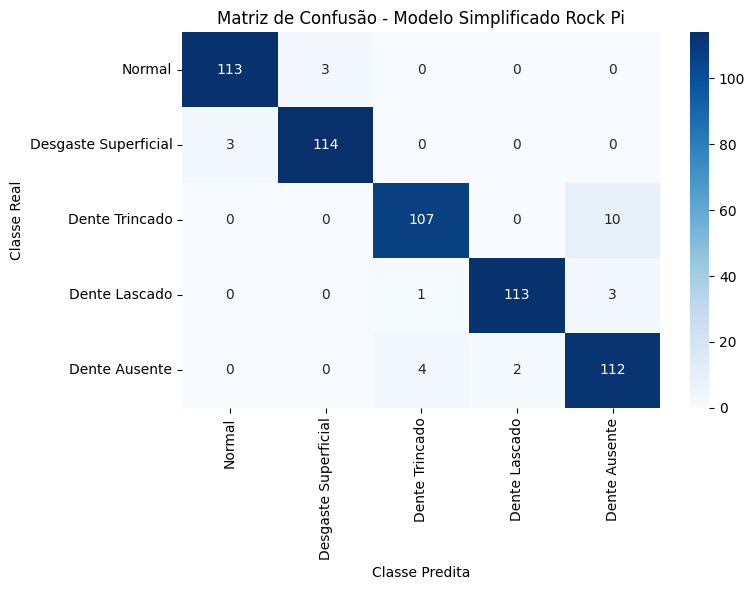

,split,dataset_operacao,classe,amostras
0,Teste,1500_10,0,58
1,Teste,1500_10,1,58
2,Teste,1500_10,2,59
3,Teste,1500_10,3,59
4,Teste,1500_10,4,59
5,Teste,2700_25,0,58
6,Teste,2700_25,1,59
7,Teste,2700_25,2,58
8,Teste,2700_25,3,58
9,Teste,2700_25,4,59


In [7]:
estrato_modelagem = (
    features_modelo["dataset_operacao"].astype(str)
    + "_classe_"
    + features_modelo["classe"].astype(str)
)

indices_treino, indices_teste = train_test_split(
    features_modelo.index.to_numpy(),
    test_size=0.3,
    random_state=42,
    stratify=estrato_modelagem,
)

X_train = X_features.loc[indices_treino].copy()
X_test = X_features.loc[indices_teste].copy()
y_train = y_features.loc[indices_treino].copy()
y_test = y_features.loc[indices_teste].copy()

metadados_train = features_modelo.loc[indices_treino, colunas_identificacao].reset_index(drop=True)
metadados_test = features_modelo.loc[indices_teste, colunas_identificacao].reset_index(drop=True)

modelo = LGBMClassifier(
    random_state=42,
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.9,
    colsample_bytree=0.9,
)
modelo.fit(X_train, y_train)

y_pred = modelo.predict(X_test)
acuracia = accuracy_score(y_test, y_pred)

print(f"Acurácia: {acuracia:.4f}")
print("\nClassification report:\n")
print(classification_report(y_test, y_pred, target_names=[mapa_classes[i] for i in sorted(mapa_classes)]))

matriz_confusao = confusion_matrix(y_test, y_pred, labels=sorted(mapa_classes))
plt.figure(figsize=(8, 6))
sns.heatmap(
    matriz_confusao,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[mapa_classes[i] for i in sorted(mapa_classes)],
    yticklabels=[mapa_classes[i] for i in sorted(mapa_classes)],
)
plt.title("Matriz de Confusão - Modelo Simplificado Rock Pi")
plt.xlabel("Classe Predita")
plt.ylabel("Classe Real")
plt.tight_layout()
plt.show()

resumo_split = pd.concat(
    [
        metadados_train.assign(split="Treino"),
        metadados_test.assign(split="Teste"),
    ],
    ignore_index=True,
)

resumo_split = (
    resumo_split.groupby(["split", "dataset_operacao", "classe"])
    .size()
    .reset_index(name="amostras")
    .sort_values(["split", "dataset_operacao", "classe"])
    .reset_index(drop=True)
)

display(resumo_split)


## 8. Exportação dos Artefatos do Modelo

In [8]:
caminho_modelo = MODEL_ARTIFACTS_DIR / "modelo_lightgbm_rockpi_simplificado.joblib"
caminho_colunas = MODEL_ARTIFACTS_DIR / "feature_columns_rockpi_simplificado.json"
caminho_metadata = MODEL_ARTIFACTS_DIR / "model_metadata_rockpi_simplificado.json"
caminho_metricas = MODEL_ARTIFACTS_DIR / "metricas_modelo_rockpi_simplificado.json"
caminho_resumo_split = MODEL_ARTIFACTS_DIR / "resumo_split_modelo_rockpi_simplificado.csv"
caminho_resumo_exportacao = MODEL_ARTIFACTS_DIR / "resumo_amostras_rockpi.csv"

joblib.dump(modelo, caminho_modelo)
caminho_colunas.write_text(json.dumps(colunas_features, ensure_ascii=False, indent=2), encoding="utf-8")

metadata_modelo = {
    "model_type": "LGBMClassifier",
    "datasets_treinados": list(config_datasets.keys()),
    "reserved_test_seconds_per_class": duracao_reserva_rockpi_s,
    "window_duration_seconds": duracao_janela_s,
    "sample_rate_hz": fs,
    "features": colunas_features,
}
caminho_metadata.write_text(json.dumps(metadata_modelo, ensure_ascii=False, indent=2), encoding="utf-8")

metricas_modelo = {
    "accuracy": float(acuracia),
    "n_train": int(X_train.shape[0]),
    "n_test": int(X_test.shape[0]),
}
caminho_metricas.write_text(json.dumps(metricas_modelo, ensure_ascii=False, indent=2), encoding="utf-8")

resumo_split.to_csv(caminho_resumo_split, index=False)
resumo_exportacao_rockpi.to_csv(caminho_resumo_exportacao, index=False)

print("Artefatos exportados:")
print("-", caminho_modelo)
print("-", caminho_colunas)
print("-", caminho_metadata)
print("-", caminho_metricas)
print("-", caminho_resumo_split)
print("-", caminho_resumo_exportacao)


Artefatos exportados:
- C:\Users\MrTatsch\Documents\trabalho_final_residencia\outputs\model_artifacts_rockpi_simplificado\modelo_lightgbm_rockpi_simplificado.joblib
- C:\Users\MrTatsch\Documents\trabalho_final_residencia\outputs\model_artifacts_rockpi_simplificado\feature_columns_rockpi_simplificado.json
- C:\Users\MrTatsch\Documents\trabalho_final_residencia\outputs\model_artifacts_rockpi_simplificado\model_metadata_rockpi_simplificado.json
- C:\Users\MrTatsch\Documents\trabalho_final_residencia\outputs\model_artifacts_rockpi_simplificado\metricas_modelo_rockpi_simplificado.json
- C:\Users\MrTatsch\Documents\trabalho_final_residencia\outputs\model_artifacts_rockpi_simplificado\resumo_split_modelo_rockpi_simplificado.csv
- C:\Users\MrTatsch\Documents\trabalho_final_residencia\outputs\model_artifacts_rockpi_simplificado\resumo_amostras_rockpi.csv
